In [ ]:
# ============================================================
# CELL 1: Cài đặt thư viện
# ============================================================

!pip install -q wandb

In [ ]:
# ============================================================
# CELL 2: Import thư viện và kiểm tra GPU
# ============================================================

import os
import json
import shutil
import zipfile
import getpass

import numpy as np
import pandas as pd
import torch
import transformers
import wandb

from collections import Counter
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)

from torch.utils.data import Dataset

from transformers import (
    LayoutLMv3Processor,
    LayoutLMv3ForTokenClassification,
    TrainingArguments,
    Trainer
)

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("W&B:", wandb.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "Không tìm thấy GPU. Hãy bật GPU trong Colab Runtime."
    )

Torch: 2.11.0+cu128
Transformers: 5.13.1
W&B: 0.28.0
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 3: Kết nối Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 4: Thiết lập đường dẫn
# ============================================================

DRIVE_DATASET_ROOT = (
    "/content/drive/MyDrive/Doan/Dataset_Layoutlmv3"
)

ZIP_PATH = os.path.join(
    DRIVE_DATASET_ROOT,
    "Layoutlmv3_Dataset.zip"
)

SPLIT_DIR = os.path.join(
    DRIVE_DATASET_ROOT,
    "splits"
)

LABEL_DIR = os.path.join(
    DRIVE_DATASET_ROOT,
    "label_mapping"
)

TRAIN_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "train_data.json"
)

VAL_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "val_data.json"
)

TEST_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "test_data.json"
)

LABEL2ID_PATH = os.path.join(
    LABEL_DIR,
    "label2id.json"
)

ID2LABEL_PATH = os.path.join(
    LABEL_DIR,
    "id2label.json"
)

# Dataset được giải nén vào bộ nhớ Colab
EXTRACT_DIR = "/content/layoutlmv3_data"

DATASET_DIR = os.path.join(
    EXTRACT_DIR,
    "valid"
)

IMAGE_DIR = os.path.join(
    DATASET_DIR,
    "images"
)

JSON_PATH = os.path.join(
    DATASET_DIR,
    "0_layoutlmv3_dataset_normalized.json"
)

# Checkpoint chỉ được lưu trong bộ nhớ Colab
CHECKPOINT_DIR = "/content/layoutlmv3_checkpoints"

BEST_MODEL_DIR = "/content/layoutlmv3_best_model"

assert os.path.exists(ZIP_PATH), (
    f"Không tìm thấy dataset ZIP: {ZIP_PATH}"
)

assert os.path.exists(TRAIN_SPLIT_PATH), (
    f"Không tìm thấy train split: {TRAIN_SPLIT_PATH}"
)

assert os.path.exists(VAL_SPLIT_PATH), (
    f"Không tìm thấy validation split: {VAL_SPLIT_PATH}"
)

assert os.path.exists(TEST_SPLIT_PATH), (
    f"Không tìm thấy test split: {TEST_SPLIT_PATH}"
)

assert os.path.exists(LABEL2ID_PATH), (
    f"Không tìm thấy label2id: {LABEL2ID_PATH}"
)

assert os.path.exists(ID2LABEL_PATH), (
    f"Không tìm thấy id2label: {ID2LABEL_PATH}"
)

print("ZIP_PATH:", ZIP_PATH)
print("SPLIT_DIR:", SPLIT_DIR)
print("LABEL_DIR:", LABEL_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

ZIP_PATH: /content/drive/MyDrive/Doan/Dataset_Layoutlmv3/Layoutlmv3_Dataset.zip
SPLIT_DIR: /content/drive/MyDrive/Doan/Dataset_Layoutlmv3/splits
LABEL_DIR: /content/drive/MyDrive/Doan/Dataset_Layoutlmv3/label_mapping
CHECKPOINT_DIR: /content/layoutlmv3_checkpoints


In [ ]:
# ============================================================
# CELL 5: Giải nén dataset từ Drive vào Colab
# ============================================================

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(
    EXTRACT_DIR,
    exist_ok=True
)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extract done:", EXTRACT_DIR)

Extract done: /content/layoutlmv3_data


In [ ]:
# ============================================================
# CELL 6: Kiểm tra cấu trúc dataset
# ============================================================

for root, dirs, files_in_folder in os.walk(EXTRACT_DIR):
    level = root.replace(
        EXTRACT_DIR,
        ""
    ).count(os.sep)

    indent = " " * 2 * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    subindent = " " * 2 * (level + 1)

    for file_name in files_in_folder[:5]:
        print(f"{subindent}{file_name}")

layoutlmv3_data/
  valid/
    0_layoutlmv3_dataset_normalized.json
    images/
      bao_viet_holdings_2024_p237_jpg.rf.c701e0b6042196b1c0995eb352483482.jpg
      vicostone_jsc_2024_p232_jpg.rf.7828714d70e984c881b40234e2b4e491.jpg
      petrovietnam_drilling_and_well_services_corp_2015_p053_jpg.rf.1626044d373d3166ba619287f93f85c4.jpg
      hoa_phat_group_jsc_2025_p081_jpg.rf.eab374d33134df5313ee620bdfd89891.jpg
      hoa_phat_group_jsc_2025_p030_jpg.rf.3f0aed6a44e2dd76d12eb534c9cb6b13.jpg


In [ ]:
# ============================================================
# CELL 7: Kiểm tra đường dẫn dataset sau khi giải nén
# ============================================================

assert os.path.exists(DATASET_DIR), (
    f"Không tìm thấy dataset directory: {DATASET_DIR}"
)

assert os.path.exists(IMAGE_DIR), (
    f"Không tìm thấy image directory: {IMAGE_DIR}"
)

assert os.path.exists(JSON_PATH), (
    f"Không tìm thấy normalized JSON: {JSON_PATH}"
)

print("DATASET_DIR:", DATASET_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("JSON_PATH:", JSON_PATH)

DATASET_DIR: /content/layoutlmv3_data/valid
IMAGE_DIR: /content/layoutlmv3_data/valid/images
JSON_PATH: /content/layoutlmv3_data/valid/0_layoutlmv3_dataset_normalized.json


In [ ]:
# ============================================================
# CELL 8: Đọc toàn bộ dataset
# ============================================================

with open(
    JSON_PATH,
    "r",
    encoding="utf-8"
) as file:
    data = json.load(file)

print("Number of pages:", len(data))

sample = data[0]

print("Sample keys:", sample.keys())
print("File name:", sample["file_name"])
print("Words:", len(sample["words"]))
print("Bboxes:", len(sample["bboxes"]))
print("Labels:", len(sample["labels"]))

sample_image_path = os.path.join(
    IMAGE_DIR,
    sample["file_name"]
)

print(
    "Image exists:",
    os.path.exists(sample_image_path)
)

Number of pages: 2466
Sample keys: dict_keys(['image_id', 'file_name', 'width', 'height', 'words', 'bboxes', 'labels', 'bbox_scale'])
File name: bao_viet_holdings_2024_p345_jpg.rf.a30d88b69fd1694f4aa1e448d0835a10.jpg
Words: 44
Bboxes: 44
Labels: 44
Image exists: True


In [ ]:
# ============================================================
# CELL 9: Kiểm tra Missing Image, Length Error và Bbox Error
# ============================================================

missing = 0
length_error = 0
bbox_error = 0

missing_files = []
length_error_files = []
bbox_error_files = []

label_counter = Counter()

for item in data:
    image_path = os.path.join(
        IMAGE_DIR,
        item["file_name"]
    )

    if not os.path.exists(image_path):
        missing += 1
        missing_files.append(
            item["file_name"]
        )

    if not (
        len(item["words"])
        == len(item["bboxes"])
        == len(item["labels"])
    ):
        length_error += 1
        length_error_files.append(
            item["file_name"]
        )

    for box in item["bboxes"]:
        if (
            len(box) != 4
            or min(box) < 0
            or max(box) > 1000
        ):
            bbox_error += 1
            bbox_error_files.append(
                item["file_name"]
            )

    label_counter.update(
        item["labels"]
    )

print("Missing images:", missing)
print("Length error:", length_error)
print("Bbox error:", bbox_error)

print("\nLabel distribution:")

for label_name, count in label_counter.items():
    print(f"{label_name}: {count}")

assert missing == 0, (
    f"Dataset có {missing} ảnh bị thiếu."
)

assert length_error == 0, (
    f"Dataset có {length_error} trang bị lệch "
    "words, bboxes và labels."
)

assert bbox_error == 0, (
    f"Dataset có {bbox_error} bounding box không hợp lệ."
)

Missing images: 0
Length error: 0
Bbox error: 0

Label distribution:
header: 5060
ignore: 12777
text: 68357
footer: 2051
toc: 19656
figure: 12095
table: 39889
chart: 5649
table_text: 13418
O: 88


In [ ]:
# ============================================================
# CELL 10: Load lại Train, Validation và Test Split từ Drive
# ============================================================

with open(
    TRAIN_SPLIT_PATH,
    "r",
    encoding="utf-8"
) as file:
    train_data = json.load(file)

with open(
    VAL_SPLIT_PATH,
    "r",
    encoding="utf-8"
) as file:
    val_data = json.load(file)

with open(
    TEST_SPLIT_PATH,
    "r",
    encoding="utf-8"
) as file:
    test_data = json.load(file)

print("Total original data:", len(data))
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

assert (
    len(train_data)
    + len(val_data)
    + len(test_data)
    == len(data)
), "Tổng số mẫu split không khớp với dataset gốc."

Total original data: 2466
Train: 1972
Validation: 247
Test: 247


In [ ]:
# ============================================================
# CELL 11: Kiểm tra file ảnh trong các split
# ============================================================

def check_split_images(
    split_data,
    split_name,
    image_dir
):
    missing_split_images = []

    for item in split_data:
        image_path = os.path.join(
            image_dir,
            item["file_name"]
        )

        if not os.path.exists(image_path):
            missing_split_images.append(
                item["file_name"]
            )

    print(
        f"{split_name} missing images:",
        len(missing_split_images)
    )

    return missing_split_images


train_missing = check_split_images(
    train_data,
    "Train",
    IMAGE_DIR
)

val_missing = check_split_images(
    val_data,
    "Validation",
    IMAGE_DIR
)

test_missing = check_split_images(
    test_data,
    "Test",
    IMAGE_DIR
)

assert len(train_missing) == 0
assert len(val_missing) == 0
assert len(test_missing) == 0

Train missing images: 0
Validation missing images: 0
Test missing images: 0


In [ ]:
# ============================================================
# CELL 12: Load lại Label Mapping từ Drive
# ============================================================

with open(
    LABEL2ID_PATH,
    "r",
    encoding="utf-8"
) as file:
    label2id = json.load(file)

with open(
    ID2LABEL_PATH,
    "r",
    encoding="utf-8"
) as file:
    loaded_id2label = json.load(file)

# JSON lưu key dưới dạng chuỗi nên cần chuyển lại thành int
id2label = {
    int(label_id): label_name
    for label_id, label_name
    in loaded_id2label.items()
}

labels = [
    label_name
    for label_name, label_id
    in sorted(
        label2id.items(),
        key=lambda item: item[1]
    )
]

print("Labels:", labels)
print("Label to ID:", label2id)
print("ID to Label:", id2label)

Labels: ['O', 'chart', 'figure', 'footer', 'header', 'ignore', 'table', 'table_text', 'text', 'toc']
Label to ID: {'O': 0, 'chart': 1, 'figure': 2, 'footer': 3, 'header': 4, 'ignore': 5, 'table': 6, 'table_text': 7, 'text': 8, 'toc': 9}
ID to Label: {0: 'O', 1: 'chart', 2: 'figure', 3: 'footer', 4: 'header', 5: 'ignore', 6: 'table', 7: 'table_text', 8: 'text', 9: 'toc'}


In [ ]:
# ============================================================
# CELL 13: Kiểm tra Label Mapping
# ============================================================

all_labels_in_data = set()

for item in data:
    all_labels_in_data.update(
        item["labels"]
    )

unknown_labels = (
    all_labels_in_data
    - set(labels)
)

missing_labels = (
    set(labels)
    - all_labels_in_data
)

print("Unknown labels:", unknown_labels)
print("Labels not appearing:", missing_labels)

assert len(unknown_labels) == 0, (
    f"Dataset có label lạ: {unknown_labels}"
)

assert len(label2id) == len(id2label), (
    "label2id và id2label không cùng số lượng label."
)

for label_name, label_id in label2id.items():
    assert id2label[int(label_id)] == label_name, (
        f"Label mapping không khớp: {label_name}"
    )

Unknown labels: set()
Labels not appearing: set()


In [ ]:
# ============================================================
# CELL 14: Nhập W&B API Key
# ============================================================

WANDB_API_KEY = getpass.getpass(
    "Nhập Weights & Biases API Key: "
)

assert WANDB_API_KEY.strip(), (
    "W&B API Key không được để trống."
)

wandb.login(
    key=WANDB_API_KEY,
    relogin=True
)

del WANDB_API_KEY

print("Đăng nhập Weights & Biases thành công.")

Nhập Weights & Biases API Key: ··········


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: haotqse180011 (haotqse180011-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Đăng nhập Weights & Biases thành công.


In [ ]:
# ============================================================
# CELL 15: Load LayoutLMv3 Processor
# ============================================================

processor = LayoutLMv3Processor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=False
)

print("Processor loaded.")

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Processor loaded.


In [ ]:
# ============================================================
# CELL 16: Tạo PyTorch Dataset
# ============================================================

class LayoutDataset(Dataset):
    def __init__(
        self,
        examples,
        image_dir,
        processor,
        label2id,
        max_length=512
    ):
        self.examples = examples
        self.image_dir = image_dir
        self.processor = processor
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        item = self.examples[idx]

        image_path = os.path.join(
            self.image_dir,
            item["file_name"]
        )

        if not os.path.exists(image_path):
            raise FileNotFoundError(
                f"Không tìm thấy ảnh: {image_path}"
            )

        image = Image.open(
            image_path
        ).convert("RGB")

        words = item["words"]
        boxes = item["bboxes"]
        labels_item = item["labels"]

        if not (
            len(words)
            == len(boxes)
            == len(labels_item)
        ):
            raise ValueError(
                "Số lượng words, bboxes và labels "
                f"không khớp tại {item['file_name']}"
            )

        word_labels = [
            self.label2id[label]
            for label in labels_item
        ]

        encoding = self.processor(
            image,
            words,
            boxes=boxes,
            word_labels=word_labels,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        encoding = {
            key: value.squeeze(0)
            for key, value
            in encoding.items()
        }

        return encoding

In [ ]:
# ============================================================
# CELL 17: Tạo Train, Validation và Test Dataset
# ============================================================

MAX_LENGTH = 512

train_dataset = LayoutDataset(
    train_data,
    IMAGE_DIR,
    processor,
    label2id,
    max_length=MAX_LENGTH
)

val_dataset = LayoutDataset(
    val_data,
    IMAGE_DIR,
    processor,
    label2id,
    max_length=MAX_LENGTH
)

test_dataset = LayoutDataset(
    test_data,
    IMAGE_DIR,
    processor,
    label2id,
    max_length=MAX_LENGTH
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 1972
Validation dataset: 247
Test dataset: 247


In [ ]:
# ============================================================
# CELL 18: Kiểm tra một Sample Encoding
# ============================================================

sample_encoding = train_dataset[0]

for key, value in sample_encoding.items():
    print(key, value.shape)

input_ids torch.Size([512])
attention_mask torch.Size([512])
bbox torch.Size([512, 4])
labels torch.Size([512])
pixel_values torch.Size([3, 224, 224])


In [ ]:
# ============================================================
# CELL 19: Load LayoutLMv3 Model
# ============================================================

model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("Model loaded.")
print("Number of labels:", model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.weight    | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.out_proj.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Number of labels: 10


In [ ]:
# ============================================================
# CELL 20: Metric đánh giá mô hình
# ============================================================

def compute_metrics(eval_prediction):
    predictions, label_ids = eval_prediction

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predicted_ids = np.argmax(
        predictions,
        axis=-1
    )

    # Loại bỏ padding, special token và ignored subword
    valid_mask = label_ids != -100

    true_ids = label_ids[
        valid_mask
    ].astype(int)

    predicted_ids = predicted_ids[
        valid_mask
    ].astype(int)

    accuracy = accuracy_score(
        true_ids,
        predicted_ids
    )

    (
        micro_precision,
        micro_recall,
        micro_f1,
        _
    ) = precision_recall_fscore_support(
        true_ids,
        predicted_ids,
        labels=list(range(len(labels))),
        average="micro",
        zero_division=0
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = precision_recall_fscore_support(
        true_ids,
        predicted_ids,
        labels=list(range(len(labels))),
        average="macro",
        zero_division=0
    )

    (
        weighted_precision,
        weighted_recall,
        weighted_f1,
        _
    ) = precision_recall_fscore_support(
        true_ids,
        predicted_ids,
        labels=list(range(len(labels))),
        average="weighted",
        zero_division=0
    )

    labels_without_o = [
        label_id
        for label_name, label_id
        in label2id.items()
        if label_name != "O"
    ]

    (
        macro_precision_no_o,
        macro_recall_no_o,
        macro_f1_no_o,
        _
    ) = precision_recall_fscore_support(
        true_ids,
        predicted_ids,
        labels=labels_without_o,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy":
            float(accuracy),

        "micro_precision":
            float(micro_precision),

        "micro_recall":
            float(micro_recall),

        "micro_f1":
            float(micro_f1),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "weighted_precision":
            float(weighted_precision),

        "weighted_recall":
            float(weighted_recall),

        "weighted_f1":
            float(weighted_f1),

        "macro_precision_no_o":
            float(macro_precision_no_o),

        "macro_recall_no_o":
            float(macro_recall_no_o),

        "macro_f1_no_o":
            float(macro_f1_no_o),

        "evaluated_tokens":
            int(len(true_ids))
    }

In [ ]:
# ============================================================
# CELL 21: Khởi tạo W&B Project
# ============================================================

WANDB_PROJECT_NAME = "layoutlmv3"
WANDB_RUN_NAME = "layoutlmv3-finetune-10-epochs"

wandb_run = wandb.init(
    project=WANDB_PROJECT_NAME,
    name=WANDB_RUN_NAME,
    config={
        "base_model":
            "microsoft/layoutlmv3-base",

        "task":
            "token-classification",

        "num_labels":
            len(labels),

        "labels":
            labels,

        "max_length":
            MAX_LENGTH,

        "train_pages":
            len(train_dataset),

        "validation_pages":
            len(val_dataset),

        "test_pages":
            len(test_dataset),

        "per_device_train_batch_size":
            1,

        "per_device_eval_batch_size":
            1,

        "gradient_accumulation_steps":
            8,

        "effective_batch_size":
            8,

        "learning_rate":
            5e-5,

        "num_train_epochs":
            10,

        "weight_decay":
            0.01,

        "logging_steps":
            50,

        "eval_steps":
            250,

        "save_steps":
            250,

        "random_state":
            42
    }
)

print("W&B Project:", wandb_run.project)
print("W&B Run:", wandb_run.name)
print("W&B URL:", wandb_run.url)

W&B Project: Layoutlmv3
W&B Run: layoutlmv3-finetune-10-epochs
W&B URL: https://wandb.ai/haotqse180011-fpt-university/Layoutlmv3/runs/cpz3b7ie


In [ ]:
# ============================================================
# CELL 22: Log phân bố Label lên W&B
# ============================================================

train_label_counter = Counter()

for item in train_data:
    train_label_counter.update(
        item["labels"]
    )

label_distribution_table = wandb.Table(
    columns=[
        "label",
        "train_token_count"
    ]
)

for label_name in labels:
    label_distribution_table.add_data(
        label_name,
        train_label_counter.get(
            label_name,
            0
        )
    )

wandb.log({
    "dataset/train_label_distribution_table":
        label_distribution_table
})

wandb.log({
    "dataset/train_label_distribution_chart":
        wandb.plot.bar(
            label_distribution_table,
            "label",
            "train_token_count",
            title="Train Label Distribution"
        )
})

In [ ]:
# ============================================================
# CELL 23: Tạo thư mục Checkpoint trong Colab
# ============================================================

if os.path.exists(CHECKPOINT_DIR):
    shutil.rmtree(CHECKPOINT_DIR)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print("Checkpoint directory:", CHECKPOINT_DIR)

Checkpoint directory: /content/layoutlmv3_checkpoints


In [ ]:
# ============================================================
# CELL 24: TrainingArguments
# ============================================================

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=5e-5,
    num_train_epochs=10,
    weight_decay=0.01,

    logging_strategy="steps",
    logging_steps=50,
    logging_first_step=True,

    eval_strategy="steps",
    eval_steps=250,

    save_strategy="steps",
    save_steps=250,

    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=True,

    report_to=["wandb"],
    run_name=WANDB_RUN_NAME,

    remove_unused_columns=False
)

In [ ]:
# ============================================================
# CELL 25: Tạo Trainer
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=processor,

    compute_metrics=compute_metrics
)

print("Trainer created.")

Trainer created.


In [ ]:
# ============================================================
# CELL 26: Training
# ============================================================

train_result = trainer.train()

print("===== Training Result =====")

for metric_name, metric_value in train_result.metrics.items():
    if isinstance(metric_value, float):
        print(
            f"{metric_name}: "
            f"{metric_value:.6f}"
        )
    else:
        print(
            f"{metric_name}: "
            f"{metric_value}"
        )

Step,Training Loss,Validation Loss,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision No O,Macro Recall No O,Macro F1 No O,Evaluated Tokens
250,4.503459,0.559002,0.845754,0.845754,0.845754,0.845754,0.632541,0.618104,0.603798,0.849158,0.845754,0.834128,0.702824,0.686782,0.670887,13070
500,3.247731,0.388855,0.891813,0.891813,0.891813,0.891813,0.724920,0.720958,0.719805,0.889600,0.891813,0.888863,0.805467,0.801064,0.799783,13070
750,2.887953,0.410113,0.885845,0.885845,0.885845,0.885845,0.778011,0.677547,0.709429,0.892993,0.885845,0.880399,0.864457,0.752831,0.788255,13070
1000,2.338605,0.381249,0.905279,0.905279,0.905279,0.905279,0.774357,0.734990,0.744580,0.907552,0.905279,0.899147,0.860397,0.816656,0.827311,13070
1250,1.707313,0.336829,0.909105,0.909105,0.909105,0.909105,0.750357,0.745174,0.743365,0.908265,0.909105,0.906138,0.833730,0.827971,0.825961,13070
1500,0.989659,0.379182,0.911477,0.911477,0.911477,0.911477,0.764117,0.756483,0.754634,0.917442,0.911477,0.911064,0.849019,0.840536,0.838482,13070
1750,0.693243,0.407507,0.918133,0.918133,0.918133,0.918133,0.762957,0.765899,0.761622,0.919019,0.918133,0.917306,0.847730,0.850999,0.846247,13070
2000,0.483311,0.446322,0.915073,0.915073,0.915073,0.915073,0.770900,0.748645,0.754576,0.913683,0.915073,0.910830,0.856555,0.831828,0.838418,13070
2250,0.323027,0.416866,0.919816,0.919816,0.919816,0.919816,0.772078,0.759931,0.761189,0.919151,0.919816,0.916477,0.857865,0.844367,0.845766,13070
2470,0.410453,0.408467,0.924407,0.924407,0.924407,0.924407,0.778378,0.769569,0.770584,0.924273,0.924407,0.922290,0.864865,0.855077,0.856205,13070


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

===== Training Result =====
train_runtime: 8396.123200
train_samples_per_second: 2.349000
train_steps_per_second: 0.294000
total_flos: 5234215095091200.000000
train_loss: 2.056983
epoch: 10.000000


In [ ]:
# ============================================================
# CELL 27: Kiểm tra Checkpoint tốt nhất
# ============================================================

print(
    "Best checkpoint:",
    trainer.state.best_model_checkpoint
)

print(
    "Best metric:",
    trainer.state.best_metric
)

Best checkpoint: /content/layoutlmv3_checkpoints/checkpoint-1250
Best metric: 0.33682864904403687


In [ ]:
# ============================================================
# CELL 28: Đánh giá trên Test Set
# ============================================================

test_result = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test"
)

print("===== Test Result =====")

for metric_name, metric_value in test_result.items():
    if isinstance(metric_value, float):
        print(
            f"{metric_name}: "
            f"{metric_value:.6f}"
        )
    else:
        print(
            f"{metric_name}: "
            f"{metric_value}"
        )

Training Loss,Validation Loss,Step,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision No O,Macro Recall No O,Macro F1 No O,Evaluated Tokens
0.410453,0.414138,2470,0.888843,0.888843,0.888843,0.888843,0.745037,0.724540,0.733179,0.886692,0.888843,0.887190,0.827819,0.805044,0.814644,14583


===== Test Result =====
test_loss: 0.414138
test_accuracy: 0.888843
test_micro_precision: 0.888843
test_micro_recall: 0.888843
test_micro_f1: 0.888843
test_macro_precision: 0.745037
test_macro_recall: 0.724540
test_macro_f1: 0.733179
test_weighted_precision: 0.886692
test_weighted_recall: 0.888843
test_weighted_f1: 0.887190
test_macro_precision_no_o: 0.827819
test_macro_recall_no_o: 0.805044
test_macro_f1_no_o: 0.814644
test_evaluated_tokens: 14583


In [ ]:
# ============================================================
# CELL 29: Predict trên Test Set
# ============================================================

prediction_output = trainer.predict(
    test_dataset,
    metric_key_prefix="test_prediction"
)

logits = prediction_output.predictions
labels_true = prediction_output.label_ids

if isinstance(logits, tuple):
    logits = logits[0]

predicted_ids = np.argmax(
    logits,
    axis=-1
)

valid_mask = labels_true != -100

true_label_ids = labels_true[
    valid_mask
].astype(int)

predicted_label_ids = predicted_ids[
    valid_mask
].astype(int)

true_labels = [
    id2label[int(label_id)]
    for label_id in true_label_ids
]

pred_labels = [
    id2label[int(label_id)]
    for label_id in predicted_label_ids
]

print(
    "Number of evaluated tokens:",
    len(true_label_ids)
)

Number of evaluated tokens: 14583


In [ ]:
# ============================================================
# CELL 30: Classification Report
# ============================================================

report_text = classification_report(
    true_label_ids,
    predicted_label_ids,
    labels=list(range(len(labels))),
    target_names=labels,
    digits=4,
    zero_division=0
)

print(report_text)

report_dict = classification_report(
    true_label_ids,
    predicted_label_ids,
    labels=list(range(len(labels))),
    target_names=labels,
    output_dict=True,
    zero_division=0
)

report_dataframe = pd.DataFrame(
    report_dict
).transpose()

display(report_dataframe)

              precision    recall  f1-score   support

           O     0.0000    0.0000    0.0000         4
       chart     0.9061    0.8654    0.8853       379
      figure     0.7876    0.6711    0.7247      1061
      footer     0.6471    0.4972    0.5623       177
      header     0.8477    0.8858    0.8663       578
      ignore     0.7483    0.7317    0.7399       902
       table     0.9359    0.9373    0.9366      3364
  table_text     0.7130    0.7428    0.7276       863
        text     0.9164    0.9355    0.9259      5380
         toc     0.9483    0.9787    0.9633      1875

    accuracy                         0.8888     14583
   macro avg     0.7450    0.7245    0.7332     14583
weighted avg     0.8867    0.8888    0.8872     14583



,precision,recall,f1-score,support
O,0.000000,0.000000,0.000000,4.000000
chart,0.906077,0.865435,0.885290,379.000000
figure,0.787611,0.671065,0.724682,1061.000000
footer,0.647059,0.497175,0.562300,177.000000
header,0.847682,0.885813,0.866328,578.000000
ignore,0.748299,0.731707,0.739910,902.000000
table,0.935886,0.937277,0.936581,3364.000000
table_text,0.713014,0.742758,0.727582,863.000000
text,0.916424,0.935502,0.925865,5380.000000
toc,0.948320,0.978667,0.963255,1875.000000


In [ ]:
# ============================================================
# CELL 31: Tính Overall Metrics
# ============================================================

accuracy = accuracy_score(
    true_label_ids,
    predicted_label_ids
)

(
    micro_precision,
    micro_recall,
    micro_f1,
    _
) = precision_recall_fscore_support(
    true_label_ids,
    predicted_label_ids,
    labels=list(range(len(labels))),
    average="micro",
    zero_division=0
)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _
) = precision_recall_fscore_support(
    true_label_ids,
    predicted_label_ids,
    labels=list(range(len(labels))),
    average="macro",
    zero_division=0
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _
) = precision_recall_fscore_support(
    true_label_ids,
    predicted_label_ids,
    labels=list(range(len(labels))),
    average="weighted",
    zero_division=0
)

labels_without_o = [
    label_id
    for label_name, label_id
    in label2id.items()
    if label_name != "O"
]

(
    macro_precision_no_o,
    macro_recall_no_o,
    macro_f1_no_o,
    _
) = precision_recall_fscore_support(
    true_label_ids,
    predicted_label_ids,
    labels=labels_without_o,
    average="macro",
    zero_division=0
)

print("===== Overall Benchmarks =====")

print(
    f"Token Accuracy        : "
    f"{accuracy:.4f}"
)

print(
    f"Micro Precision       : "
    f"{micro_precision:.4f}"
)

print(
    f"Micro Recall          : "
    f"{micro_recall:.4f}"
)

print(
    f"Micro F1              : "
    f"{micro_f1:.4f}"
)

print(
    f"Macro Precision       : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall          : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1              : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted Precision    : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted Recall       : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1           : "
    f"{weighted_f1:.4f}"
)

print(
    f"Macro Precision No O  : "
    f"{macro_precision_no_o:.4f}"
)

print(
    f"Macro Recall No O     : "
    f"{macro_recall_no_o:.4f}"
)

print(
    f"Macro F1 No O         : "
    f"{macro_f1_no_o:.4f}"
)

===== Overall Benchmarks =====
Token Accuracy        : 0.8888
Micro Precision       : 0.8888
Micro Recall          : 0.8888
Micro F1              : 0.8888
Macro Precision       : 0.7450
Macro Recall          : 0.7245
Macro F1              : 0.7332
Weighted Precision    : 0.8867
Weighted Recall       : 0.8888
Weighted F1           : 0.8872
Macro Precision No O  : 0.8278
Macro Recall No O     : 0.8050
Macro F1 No O         : 0.8146


In [ ]:
# ============================================================
# CELL 32: Log Classification Report lên W&B
# ============================================================

classification_table_dataframe = (
    report_dataframe
    .reset_index()
    .rename(
        columns={
            "index": "label"
        }
    )
)

classification_table = wandb.Table(
    dataframe=classification_table_dataframe
)

wandb.log({
    "test/classification_report":
        classification_table
})

In [ ]:
# ============================================================
# CELL 33: Log Overall Metrics lên W&B
# ============================================================

final_test_metrics = {
    "final_test/token_accuracy":
        float(accuracy),

    "final_test/micro_precision":
        float(micro_precision),

    "final_test/micro_recall":
        float(micro_recall),

    "final_test/micro_f1":
        float(micro_f1),

    "final_test/macro_precision":
        float(macro_precision),

    "final_test/macro_recall":
        float(macro_recall),

    "final_test/macro_f1":
        float(macro_f1),

    "final_test/weighted_precision":
        float(weighted_precision),

    "final_test/weighted_recall":
        float(weighted_recall),

    "final_test/weighted_f1":
        float(weighted_f1),

    "final_test/macro_precision_no_o":
        float(macro_precision_no_o),

    "final_test/macro_recall_no_o":
        float(macro_recall_no_o),

    "final_test/macro_f1_no_o":
        float(macro_f1_no_o),

    "final_test/evaluated_tokens":
        int(len(true_label_ids))
}

wandb.log(final_test_metrics)

In [ ]:
# ============================================================
# CELL 34: Log Confusion Matrix lên W&B
# ============================================================

confusion_matrix_plot = wandb.plot.confusion_matrix(
    y_true=true_label_ids.tolist(),
    preds=predicted_label_ids.tolist(),
    class_names=labels
)

wandb.log({
    "test/confusion_matrix":
        confusion_matrix_plot
})

In [ ]:
# ============================================================
# CELL 35: Lưu Best Model trong Colab
# ============================================================

if os.path.exists(BEST_MODEL_DIR):
    shutil.rmtree(BEST_MODEL_DIR)

os.makedirs(
    BEST_MODEL_DIR,
    exist_ok=True
)

trainer.save_model(
    BEST_MODEL_DIR
)

processor.save_pretrained(
    BEST_MODEL_DIR
)

print(
    "Best model saved to:",
    BEST_MODEL_DIR
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/layoutlmv3_best_model


In [ ]:
# ============================================================
# CELL 36: Kiểm tra các file Model đã lưu
# ============================================================

for file_name in sorted(
    os.listdir(BEST_MODEL_DIR)
):
    file_path = os.path.join(
        BEST_MODEL_DIR,
        file_name
    )

    if os.path.isfile(file_path):
        file_size_mb = (
            os.path.getsize(file_path)
            / (1024 * 1024)
        )

        print(
            f"{file_name}: "
            f"{file_size_mb:.2f} MB"
        )

config.json: 0.00 MB
model.safetensors: 480.39 MB
processor_config.json: 0.00 MB
tokenizer.json: 3.39 MB
tokenizer_config.json: 0.00 MB
training_args.bin: 0.00 MB


In [ ]:
# ============================================================
# CELL 38: Kiểm tra toàn bộ checkpoint hiện có
# ============================================================

import os
import re

checkpoint_paths = [
    os.path.join(CHECKPOINT_DIR, folder_name)
    for folder_name in os.listdir(CHECKPOINT_DIR)
    if (
        folder_name.startswith("checkpoint-")
        and os.path.isdir(
            os.path.join(CHECKPOINT_DIR, folder_name)
        )
    )
]


def get_checkpoint_step(checkpoint_path):
    checkpoint_name = os.path.basename(checkpoint_path)

    match = re.search(
        r"checkpoint-(\d+)",
        checkpoint_name
    )

    if match is None:
        return -1

    return int(match.group(1))


checkpoint_paths = sorted(
    checkpoint_paths,
    key=get_checkpoint_step
)

assert len(checkpoint_paths) > 0, (
    f"Không tìm thấy checkpoint trong {CHECKPOINT_DIR}"
)

print(
    "Số checkpoint hiện có:",
    len(checkpoint_paths)
)

for checkpoint_path in checkpoint_paths:
    print(checkpoint_path)

Số checkpoint hiện có: 3
/content/layoutlmv3_checkpoints/checkpoint-1250
/content/layoutlmv3_checkpoints/checkpoint-2250
/content/layoutlmv3_checkpoints/checkpoint-2470


In [ ]:
# ============================================================
# CELL 39: Nén và tải toàn bộ checkpoint về máy
# ============================================================

import os
import shutil

from google.colab import files

ALL_CHECKPOINTS_ZIP = (
    "/content/layoutlmv3_all_checkpoints.zip"
)

if os.path.exists(ALL_CHECKPOINTS_ZIP):
    os.remove(ALL_CHECKPOINTS_ZIP)

shutil.make_archive(
    base_name="/content/layoutlmv3_all_checkpoints",
    format="zip",
    root_dir=os.path.dirname(CHECKPOINT_DIR),
    base_dir=os.path.basename(CHECKPOINT_DIR)
)

zip_size_mb = (
    os.path.getsize(ALL_CHECKPOINTS_ZIP)
    / (1024 * 1024)
)

print("Checkpoint ZIP:", ALL_CHECKPOINTS_ZIP)
print(f"ZIP size: {zip_size_mb:.2f} MB")

files.download(ALL_CHECKPOINTS_ZIP)

Checkpoint ZIP: /content/layoutlmv3_all_checkpoints.zip
ZIP size: 3506.10 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 40: Import metric bổ sung để benchmark checkpoint
# ============================================================

import gc
import json
import time

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    balanced_accuracy_score,
    cohen_kappa_score,
    hamming_loss,
    jaccard_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_fscore_support
)

from transformers import (
    LayoutLMv3ForTokenClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
# ============================================================
# CELL 41: Các hàm hỗ trợ benchmark
# ============================================================

def get_directory_size_mb(directory_path):
    total_size = 0

    for root, directories, file_names in os.walk(
        directory_path
    ):
        for file_name in file_names:
            file_path = os.path.join(
                root,
                file_name
            )

            if os.path.isfile(file_path):
                total_size += os.path.getsize(
                    file_path
                )

    return total_size / (1024 * 1024)


def stable_softmax(logits):
    logits = logits - np.max(
        logits,
        axis=-1,
        keepdims=True
    )

    exponential = np.exp(logits)

    return exponential / np.sum(
        exponential,
        axis=-1,
        keepdims=True
    )


def calculate_top_k_accuracy(
    probabilities,
    true_ids,
    k=2
):
    k = min(
        k,
        probabilities.shape[1]
    )

    top_k_predictions = np.argpartition(
        probabilities,
        -k,
        axis=1
    )[:, -k:]

    correct = np.any(
        top_k_predictions
        == true_ids[:, None],
        axis=1
    )

    return float(np.mean(correct))


def calculate_expected_calibration_error(
    probabilities,
    true_ids,
    number_of_bins=15
):
    predicted_ids = np.argmax(
        probabilities,
        axis=1
    )

    confidences = np.max(
        probabilities,
        axis=1
    )

    correctness = (
        predicted_ids == true_ids
    ).astype(float)

    bin_boundaries = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1
    )

    expected_calibration_error = 0.0

    for lower_bound, upper_bound in zip(
        bin_boundaries[:-1],
        bin_boundaries[1:]
    ):
        in_bin = (
            (confidences > lower_bound)
            & (confidences <= upper_bound)
        )

        bin_count = np.sum(in_bin)

        if bin_count == 0:
            continue

        bin_accuracy = np.mean(
            correctness[in_bin]
        )

        bin_confidence = np.mean(
            confidences[in_bin]
        )

        bin_weight = (
            bin_count
            / len(true_ids)
        )

        expected_calibration_error += (
            abs(
                bin_accuracy
                - bin_confidence
            )
            * bin_weight
        )

    return float(
        expected_calibration_error
    )


def calculate_multiclass_brier_score(
    probabilities,
    true_ids,
    number_of_classes
):
    true_one_hot = np.eye(
        number_of_classes
    )[true_ids]

    squared_error = (
        probabilities
        - true_one_hot
    ) ** 2

    return float(
        np.mean(
            np.sum(
                squared_error,
                axis=1
            )
        )
    )


def extract_valid_predictions(
    prediction_output
):
    logits = prediction_output.predictions
    label_ids = prediction_output.label_ids

    if isinstance(logits, tuple):
        logits = logits[0]

    valid_mask = label_ids != -100

    valid_logits = logits[
        valid_mask
    ]

    true_ids = label_ids[
        valid_mask
    ].astype(int)

    probabilities = stable_softmax(
        valid_logits
    )

    predicted_ids = np.argmax(
        probabilities,
        axis=1
    ).astype(int)

    return (
        valid_logits,
        probabilities,
        true_ids,
        predicted_ids
    )

In [ ]:
# ============================================================
# CELL 42: Tính metric bổ sung từ PredictionOutput
# ============================================================

def calculate_additional_metrics(
    prediction_output,
    metric_prefix
):
    (
        valid_logits,
        probabilities,
        true_ids,
        predicted_ids
    ) = extract_valid_predictions(
        prediction_output
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            true_ids,
            predicted_ids
        )
    )

    cohen_kappa = cohen_kappa_score(
        true_ids,
        predicted_ids
    )

    matthews_correlation = (
        matthews_corrcoef(
            true_ids,
            predicted_ids
        )
    )

    macro_jaccard = jaccard_score(
        true_ids,
        predicted_ids,
        labels=list(range(len(labels))),
        average="macro",
        zero_division=0
    )

    weighted_jaccard = jaccard_score(
        true_ids,
        predicted_ids,
        labels=list(range(len(labels))),
        average="weighted",
        zero_division=0
    )

    token_hamming_loss = hamming_loss(
        true_ids,
        predicted_ids
    )

    top_2_accuracy = (
        calculate_top_k_accuracy(
            probabilities,
            true_ids,
            k=2
        )
    )

    top_3_accuracy = (
        calculate_top_k_accuracy(
            probabilities,
            true_ids,
            k=3
        )
    )

    expected_calibration_error = (
        calculate_expected_calibration_error(
            probabilities,
            true_ids,
            number_of_bins=15
        )
    )

    brier_score = (
        calculate_multiclass_brier_score(
            probabilities,
            true_ids,
            number_of_classes=len(labels)
        )
    )

    negative_log_likelihood = log_loss(
        true_ids,
        probabilities,
        labels=list(range(len(labels)))
    )

    confidence = np.max(
        probabilities,
        axis=1
    )

    correct_mask = (
        predicted_ids == true_ids
    )

    mean_confidence = float(
        np.mean(confidence)
    )

    if np.any(correct_mask):
        mean_correct_confidence = float(
            np.mean(
                confidence[correct_mask]
            )
        )
    else:
        mean_correct_confidence = np.nan

    if np.any(~correct_mask):
        mean_incorrect_confidence = float(
            np.mean(
                confidence[~correct_mask]
            )
        )
    else:
        mean_incorrect_confidence = np.nan

    return {
        f"{metric_prefix}_balanced_accuracy":
            float(balanced_accuracy),

        f"{metric_prefix}_cohen_kappa":
            float(cohen_kappa),

        f"{metric_prefix}_matthews_corrcoef":
            float(matthews_correlation),

        f"{metric_prefix}_macro_jaccard":
            float(macro_jaccard),

        f"{metric_prefix}_weighted_jaccard":
            float(weighted_jaccard),

        f"{metric_prefix}_hamming_loss":
            float(token_hamming_loss),

        f"{metric_prefix}_top_2_accuracy":
            float(top_2_accuracy),

        f"{metric_prefix}_top_3_accuracy":
            float(top_3_accuracy),

        f"{metric_prefix}_expected_calibration_error":
            float(expected_calibration_error),

        f"{metric_prefix}_brier_score":
            float(brier_score),

        f"{metric_prefix}_negative_log_likelihood":
            float(negative_log_likelihood),

        f"{metric_prefix}_mean_confidence":
            float(mean_confidence),

        f"{metric_prefix}_mean_correct_confidence":
            float(mean_correct_confidence),

        f"{metric_prefix}_mean_incorrect_confidence":
            float(mean_incorrect_confidence)
    }

In [ ]:
# ============================================================
# CELL 43: Tạo cấu hình đánh giá checkpoint
# ============================================================

BENCHMARK_OUTPUT_DIR = (
    "/content/layoutlmv3_checkpoint_benchmark"
)

BENCHMARK_TEMP_DIR = (
    "/content/layoutlmv3_benchmark_temp"
)

if os.path.exists(BENCHMARK_OUTPUT_DIR):
    shutil.rmtree(BENCHMARK_OUTPUT_DIR)

if os.path.exists(BENCHMARK_TEMP_DIR):
    shutil.rmtree(BENCHMARK_TEMP_DIR)

os.makedirs(
    BENCHMARK_OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    BENCHMARK_TEMP_DIR,
    exist_ok=True
)

benchmark_args = TrainingArguments(
    output_dir=BENCHMARK_TEMP_DIR,

    per_device_eval_batch_size=1,

    fp16=torch.cuda.is_available(),

    report_to=[],

    remove_unused_columns=False,

    dataloader_num_workers=0,

    disable_tqdm=False
)

print(
    "Benchmark output:",
    BENCHMARK_OUTPUT_DIR
)

Benchmark output: /content/layoutlmv3_checkpoint_benchmark


In [ ]:
# ============================================================
# CELL 44: Benchmark toàn bộ checkpoint
# ============================================================

benchmark_rows = []
per_class_rows = []

trainer_best_checkpoint = None

if "trainer" in globals():
    trainer_best_checkpoint = (
        trainer.state.best_model_checkpoint
    )

trainer_best_name = (
    os.path.basename(
        trainer_best_checkpoint
    )
    if trainer_best_checkpoint
    else None
)

for checkpoint_index, checkpoint_path in enumerate(
    checkpoint_paths,
    start=1
):
    checkpoint_name = os.path.basename(
        checkpoint_path
    )

    checkpoint_step = get_checkpoint_step(
        checkpoint_path
    )

    print()
    print("=" * 70)
    print(
        f"[{checkpoint_index}/{len(checkpoint_paths)}] "
        f"Evaluating {checkpoint_name}"
    )
    print("=" * 70)

    trainer_state_path = os.path.join(
        checkpoint_path,
        "trainer_state.json"
    )

    trainer_state = {}

    if os.path.exists(trainer_state_path):
        with open(
            trainer_state_path,
            "r",
            encoding="utf-8"
        ) as file:
            trainer_state = json.load(file)

    checkpoint_epoch = trainer_state.get(
        "epoch"
    )

    checkpoint_model = (
        LayoutLMv3ForTokenClassification
        .from_pretrained(checkpoint_path)
    )

    checkpoint_trainer = Trainer(
        model=checkpoint_model,
        args=benchmark_args,
        processing_class=processor,
        compute_metrics=compute_metrics
    )

    validation_start_time = time.perf_counter()

    validation_prediction = (
        checkpoint_trainer.predict(
            val_dataset,
            metric_key_prefix="val"
        )
    )

    validation_wall_time = (
        time.perf_counter()
        - validation_start_time
    )

    test_start_time = time.perf_counter()

    test_prediction = (
        checkpoint_trainer.predict(
            test_dataset,
            metric_key_prefix="test"
        )
    )

    test_wall_time = (
        time.perf_counter()
        - test_start_time
    )

    validation_metrics = (
        validation_prediction.metrics
    )

    test_metrics = (
        test_prediction.metrics
    )

    validation_additional_metrics = (
        calculate_additional_metrics(
            validation_prediction,
            metric_prefix="val"
        )
    )

    test_additional_metrics = (
        calculate_additional_metrics(
            test_prediction,
            metric_prefix="test"
        )
    )

    model_size_mb = get_directory_size_mb(
        checkpoint_path
    )

    validation_tokens = (
        validation_metrics.get(
            "val_evaluated_tokens",
            0
        )
    )

    test_tokens = test_metrics.get(
        "test_evaluated_tokens",
        0
    )

    validation_tokens_per_second = (
        validation_tokens
        / validation_wall_time
        if validation_wall_time > 0
        else np.nan
    )

    test_tokens_per_second = (
        test_tokens
        / test_wall_time
        if test_wall_time > 0
        else np.nan
    )

    benchmark_row = {
        "checkpoint":
            checkpoint_name,

        "step":
            checkpoint_step,

        "epoch":
            checkpoint_epoch,

        "is_trainer_best":
            checkpoint_name
            == trainer_best_name,

        "model_size_mb":
            model_size_mb,

        "val_loss":
            validation_metrics.get(
                "val_loss"
            ),

        "val_accuracy":
            validation_metrics.get(
                "val_accuracy"
            ),

        "val_macro_precision":
            validation_metrics.get(
                "val_macro_precision"
            ),

        "val_macro_recall":
            validation_metrics.get(
                "val_macro_recall"
            ),

        "val_macro_f1":
            validation_metrics.get(
                "val_macro_f1"
            ),

        "val_weighted_f1":
            validation_metrics.get(
                "val_weighted_f1"
            ),

        "val_macro_f1_no_o":
            validation_metrics.get(
                "val_macro_f1_no_o"
            ),

        "val_runtime_seconds":
            validation_wall_time,

        "val_tokens_per_second":
            validation_tokens_per_second,

        "test_loss":
            test_metrics.get(
                "test_loss"
            ),

        "test_accuracy":
            test_metrics.get(
                "test_accuracy"
            ),

        "test_macro_precision":
            test_metrics.get(
                "test_macro_precision"
            ),

        "test_macro_recall":
            test_metrics.get(
                "test_macro_recall"
            ),

        "test_macro_f1":
            test_metrics.get(
                "test_macro_f1"
            ),

        "test_weighted_f1":
            test_metrics.get(
                "test_weighted_f1"
            ),

        "test_macro_f1_no_o":
            test_metrics.get(
                "test_macro_f1_no_o"
            ),

        "test_runtime_seconds":
            test_wall_time,

        "test_tokens_per_second":
            test_tokens_per_second
    }

    benchmark_row.update(
        validation_additional_metrics
    )

    benchmark_row.update(
        test_additional_metrics
    )

    benchmark_row[
        "generalization_gap_macro_f1_no_o"
    ] = (
        benchmark_row["val_macro_f1_no_o"]
        - benchmark_row["test_macro_f1_no_o"]
    )

    benchmark_rows.append(
        benchmark_row
    )

    (
        _,
        test_probabilities,
        test_true_ids,
        test_predicted_ids
    ) = extract_valid_predictions(
        test_prediction
    )

    (
        per_class_precision,
        per_class_recall,
        per_class_f1,
        per_class_support
    ) = precision_recall_fscore_support(
        test_true_ids,
        test_predicted_ids,
        labels=list(range(len(labels))),
        average=None,
        zero_division=0
    )

    per_class_jaccard = jaccard_score(
        test_true_ids,
        test_predicted_ids,
        labels=list(range(len(labels))),
        average=None,
        zero_division=0
    )

    for label_id, label_name in enumerate(
        labels
    ):
        per_class_rows.append({
            "checkpoint":
                checkpoint_name,

            "step":
                checkpoint_step,

            "label_id":
                label_id,

            "label":
                label_name,

            "precision":
                float(
                    per_class_precision[
                        label_id
                    ]
                ),

            "recall":
                float(
                    per_class_recall[
                        label_id
                    ]
                ),

            "f1":
                float(
                    per_class_f1[
                        label_id
                    ]
                ),

            "jaccard_iou":
                float(
                    per_class_jaccard[
                        label_id
                    ]
                ),

            "support":
                int(
                    per_class_support[
                        label_id
                    ]
                )
        })

    del validation_prediction
    del test_prediction
    del checkpoint_trainer
    del checkpoint_model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


[1/3] Evaluating checkpoint-1250


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]


[2/3] Evaluating checkpoint-2250


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]


[3/3] Evaluating checkpoint-2470


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# CELL 45: Tạo bảng benchmark tổng hợp
# ============================================================

benchmark_dataframe = pd.DataFrame(
    benchmark_rows
)

benchmark_dataframe = (
    benchmark_dataframe
    .sort_values(
        by=[
            "val_macro_f1_no_o",
            "val_loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

benchmark_dataframe.insert(
    0,
    "rank",
    range(
        1,
        len(benchmark_dataframe) + 1
    )
)

display_columns = [
    "rank",
    "checkpoint",
    "step",
    "epoch",
    "is_trainer_best",

    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_macro_f1_no_o",
    "val_weighted_f1",

    "test_loss",
    "test_accuracy",
    "test_macro_f1",
    "test_macro_f1_no_o",
    "test_weighted_f1",

    "test_balanced_accuracy",
    "test_matthews_corrcoef",
    "test_cohen_kappa",
    "test_macro_jaccard",

    "test_top_2_accuracy",
    "test_expected_calibration_error",
    "test_brier_score",

    "test_tokens_per_second",
    "model_size_mb"
]

print("===== CHECKPOINT BENCHMARK =====")

display(
    benchmark_dataframe[
        display_columns
    ].round(6)
)

===== CHECKPOINT BENCHMARK =====


,rank,checkpoint,step,epoch,is_trainer_best,val_loss,val_accuracy,val_macro_f1,val_macro_f1_no_o,val_weighted_f1,...,test_weighted_f1,test_balanced_accuracy,test_matthews_corrcoef,test_cohen_kappa,test_macro_jaccard,test_top_2_accuracy,test_expected_calibration_error,test_brier_score,test_tokens_per_second,model_size_mb
0,1,checkpoint-2470,2470,10.000000,False,0.408467,0.924407,0.770584,0.856205,0.922290,...,0.892807,0.737450,0.862564,0.862456,0.658103,0.958308,0.087371,0.191574,182.821438,1444.719848
1,2,checkpoint-2250,2250,9.109533,False,0.416866,0.919816,0.761189,0.845766,0.916477,...,0.892866,0.734484,0.862946,0.862771,0.657020,0.957690,0.086082,0.188320,181.888285,1444.718330
2,3,checkpoint-1250,1250,5.060852,True,0.336829,0.909105,0.743365,0.825961,0.906138,...,0.887190,0.724540,0.856955,0.856832,0.634852,0.962765,0.063339,0.180375,181.385476,1444.711457


In [ ]:
# ============================================================
# CELL 46: Xác định checkpoint tốt nhất theo từng metric
# ============================================================

best_by_validation_f1 = (
    benchmark_dataframe
    .sort_values(
        by=[
            "val_macro_f1_no_o",
            "val_loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .iloc[0]
)

best_by_validation_loss = (
    benchmark_dataframe
    .sort_values(
        by="val_loss",
        ascending=True
    )
    .iloc[0]
)

best_by_test_macro_f1 = (
    benchmark_dataframe
    .sort_values(
        by="test_macro_f1_no_o",
        ascending=False
    )
    .iloc[0]
)

best_calibrated_checkpoint = (
    benchmark_dataframe
    .sort_values(
        by="test_expected_calibration_error",
        ascending=True
    )
    .iloc[0]
)

fastest_checkpoint = (
    benchmark_dataframe
    .sort_values(
        by="test_tokens_per_second",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best checkpoint theo Validation Macro F1 No O:",
    best_by_validation_f1["checkpoint"]
)

print(
    "Validation Macro F1 No O:",
    best_by_validation_f1[
        "val_macro_f1_no_o"
    ]
)

print()

print(
    "Best checkpoint theo Validation Loss:",
    best_by_validation_loss["checkpoint"]
)

print(
    "Validation Loss:",
    best_by_validation_loss["val_loss"]
)

print()

print(
    "Checkpoint có Test Macro F1 No O cao nhất:",
    best_by_test_macro_f1["checkpoint"]
)

print(
    "Test Macro F1 No O:",
    best_by_test_macro_f1[
        "test_macro_f1_no_o"
    ]
)

print()

print(
    "Checkpoint calibration tốt nhất:",
    best_calibrated_checkpoint["checkpoint"]
)

print(
    "Test ECE:",
    best_calibrated_checkpoint[
        "test_expected_calibration_error"
    ]
)

print()

print(
    "Checkpoint inference nhanh nhất:",
    fastest_checkpoint["checkpoint"]
)

print(
    "Test tokens/second:",
    fastest_checkpoint[
        "test_tokens_per_second"
    ]
)

Best checkpoint theo Validation Macro F1 No O: checkpoint-2470
Validation Macro F1 No O: 0.8562047187274621

Best checkpoint theo Validation Loss: checkpoint-1250
Validation Loss: 0.33682864904403687

Checkpoint có Test Macro F1 No O cao nhất: checkpoint-2470
Test Macro F1 No O: 0.8342755939273747

Checkpoint calibration tốt nhất: checkpoint-1250
Test ECE: 0.06333920475485594

Checkpoint inference nhanh nhất: checkpoint-2470
Test tokens/second: 182.8214380264756


In [ ]:
# ============================================================
# CELL 47: Bảng metric chi tiết theo từng class
# ============================================================

per_class_dataframe = pd.DataFrame(
    per_class_rows
)

per_class_dataframe = (
    per_class_dataframe
    .sort_values(
        by=[
            "label",
            "step"
        ]
    )
    .reset_index(drop=True)
)

display(
    per_class_dataframe.round(6)
)

,checkpoint,step,label_id,label,precision,recall,f1,jaccard_iou,support
0,checkpoint-1250,1250,0,O,0.000000,0.000000,0.000000,0.000000,4
1,checkpoint-2250,2250,0,O,0.000000,0.000000,0.000000,0.000000,4
2,checkpoint-2470,2470,0,O,0.000000,0.000000,0.000000,0.000000,4
3,checkpoint-1250,1250,1,chart,0.906077,0.865435,0.885290,0.794189,379
4,checkpoint-2250,2250,1,chart,0.938005,0.918206,0.928000,0.865672,379
5,checkpoint-2470,2470,1,chart,0.945205,0.910290,0.927419,0.864662,379
6,checkpoint-1250,1250,2,figure,0.787611,0.671065,0.724682,0.568236,1061
7,checkpoint-2250,2250,2,figure,0.738337,0.686145,0.711285,0.551933,1061
8,checkpoint-2470,2470,2,figure,0.713867,0.688973,0.701199,0.539882,1061
9,checkpoint-1250,1250,3,footer,0.647059,0.497175,0.562300,0.391111,177


In [ ]:
# ============================================================
# CELL 48: Bảng so sánh F1 của từng class giữa checkpoint
# ============================================================

per_class_f1_pivot = (
    per_class_dataframe
    .pivot(
        index="label",
        columns="checkpoint",
        values="f1"
    )
    .reset_index()
)

per_class_f1_pivot.columns.name = None

display(
    per_class_f1_pivot.round(6)
)

,label,checkpoint-1250,checkpoint-2250,checkpoint-2470
0,O,0.000000,0.000000,0.000000
1,chart,0.885290,0.928000,0.927419
2,figure,0.724682,0.711285,0.701199
3,footer,0.562300,0.675768,0.675768
4,header,0.866328,0.857658,0.868881
5,ignore,0.739910,0.720740,0.723520
6,table,0.936581,0.940158,0.939258
7,table_text,0.727582,0.760227,0.763533
8,text,0.925865,0.927621,0.927852
9,toc,0.963255,0.981050,0.981050


In [ ]:
# ============================================================
# CELL 49: Bảng so sánh IoU/Jaccard của từng class
# ============================================================

per_class_iou_pivot = (
    per_class_dataframe
    .pivot(
        index="label",
        columns="checkpoint",
        values="jaccard_iou"
    )
    .reset_index()
)

per_class_iou_pivot.columns.name = None

display(
    per_class_iou_pivot.round(6)
)

,label,checkpoint-1250,checkpoint-2250,checkpoint-2470
0,O,0.000000,0.000000,0.000000
1,chart,0.794189,0.865672,0.864662
2,figure,0.568236,0.551933,0.539882
3,footer,0.391111,0.510309,0.510309
4,header,0.764179,0.750789,0.768161
5,ignore,0.587189,0.563404,0.566809
6,table,0.880726,0.887074,0.885472
7,table_text,0.571811,0.613199,0.617512
8,text,0.861963,0.865012,0.865414
9,toc,0.929114,0.962806,0.962806


In [ ]:
# ============================================================
# CELL 50: Xác định checkpoint tốt nhất cho từng class
# ============================================================

best_checkpoint_per_class = (
    per_class_dataframe
    .sort_values(
        by=[
            "label",
            "f1"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "label",
        as_index=False
    )
    .first()
)

best_checkpoint_per_class = (
    best_checkpoint_per_class[
        [
            "label",
            "checkpoint",
            "step",
            "precision",
            "recall",
            "f1",
            "jaccard_iou",
            "support"
        ]
    ]
)

display(
    best_checkpoint_per_class.round(6)
)

,label,checkpoint,step,precision,recall,f1,jaccard_iou,support
0,O,checkpoint-1250,1250,0.000000,0.000000,0.000000,0.000000,4
1,chart,checkpoint-2250,2250,0.938005,0.918206,0.928000,0.865672,379
2,figure,checkpoint-1250,1250,0.787611,0.671065,0.724682,0.568236,1061
3,footer,checkpoint-2250,2250,0.853448,0.559322,0.675768,0.510309,177
4,header,checkpoint-2470,2470,0.878092,0.859862,0.868881,0.768161,578
5,ignore,checkpoint-1250,1250,0.748299,0.731707,0.739910,0.587189,902
6,table,checkpoint-2250,2250,0.943962,0.936385,0.940158,0.887074,3364
7,table_text,checkpoint-2470,2470,0.751121,0.776362,0.763533,0.617512,863
8,text,checkpoint-2470,2470,0.914291,0.941822,0.927852,0.865414,5380
9,toc,checkpoint-2250,2250,0.996152,0.966400,0.981050,0.962806,1875


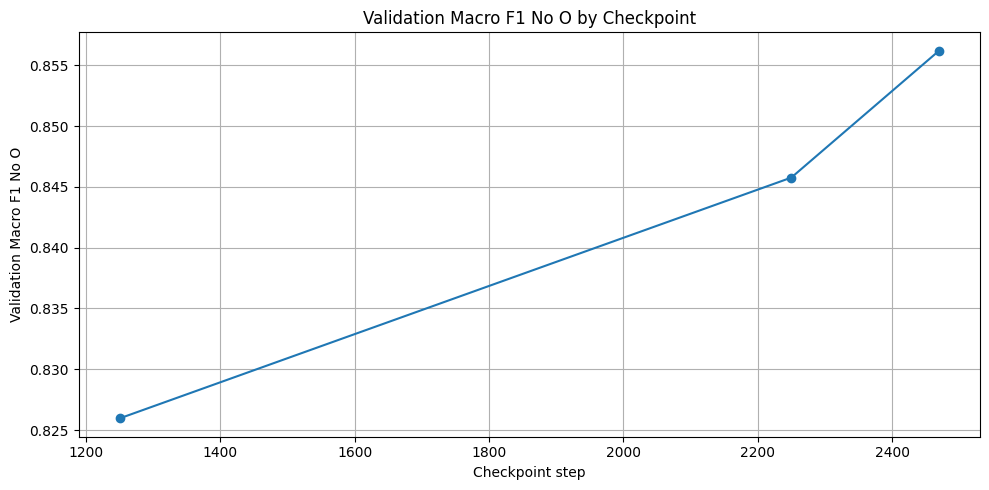

In [ ]:
# ============================================================
# CELL 51: Vẽ Validation Macro F1 No O theo checkpoint
# ============================================================

import matplotlib.pyplot as plt

plot_dataframe = (
    benchmark_dataframe
    .sort_values("step")
)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_dataframe["step"],
    plot_dataframe["val_macro_f1_no_o"],
    marker="o"
)

plt.xlabel("Checkpoint step")
plt.ylabel("Validation Macro F1 No O")
plt.title(
    "Validation Macro F1 No O by Checkpoint"
)

plt.grid(True)
plt.tight_layout()

validation_f1_plot_path = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "validation_macro_f1_no_o.png"
)

plt.savefig(
    validation_f1_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

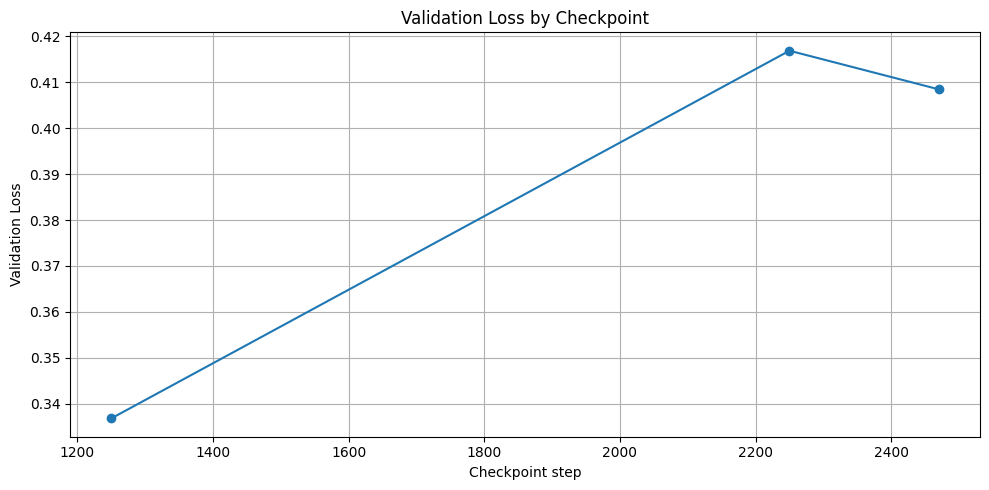

In [ ]:
# ============================================================
# CELL 52: Vẽ Validation Loss theo checkpoint
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    plot_dataframe["step"],
    plot_dataframe["val_loss"],
    marker="o"
)

plt.xlabel("Checkpoint step")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss by Checkpoint"
)

plt.grid(True)
plt.tight_layout()

validation_loss_plot_path = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "validation_loss.png"
)

plt.savefig(
    validation_loss_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

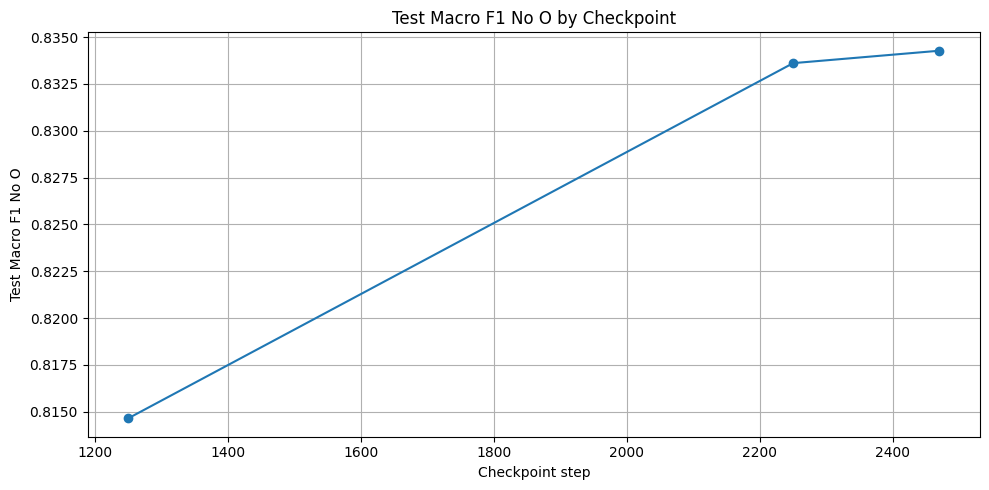

In [ ]:
# ============================================================
# CELL 53: Vẽ Test Macro F1 No O theo checkpoint
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    plot_dataframe["step"],
    plot_dataframe["test_macro_f1_no_o"],
    marker="o"
)

plt.xlabel("Checkpoint step")
plt.ylabel("Test Macro F1 No O")
plt.title(
    "Test Macro F1 No O by Checkpoint"
)

plt.grid(True)
plt.tight_layout()

test_f1_plot_path = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "test_macro_f1_no_o.png"
)

plt.savefig(
    test_f1_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

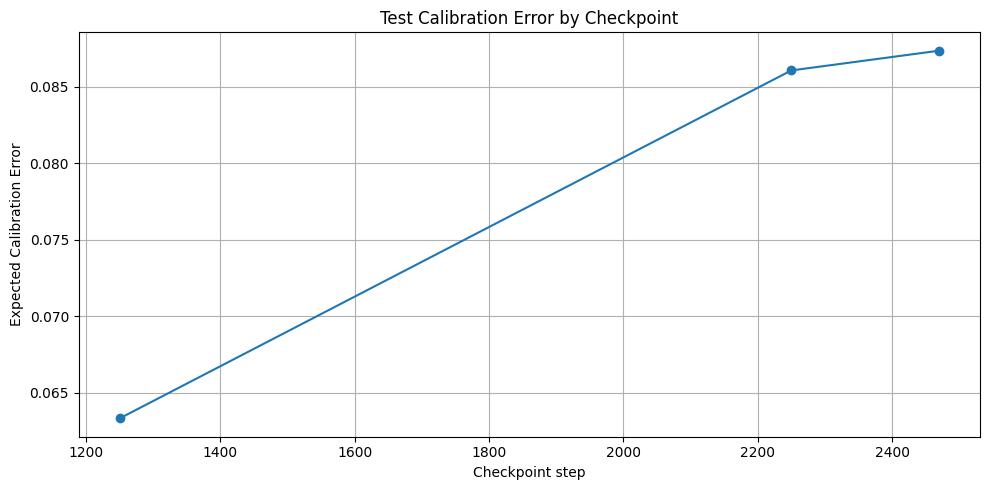

In [ ]:
# ============================================================
# CELL 54: Vẽ Expected Calibration Error
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    plot_dataframe["step"],
    plot_dataframe[
        "test_expected_calibration_error"
    ],
    marker="o"
)

plt.xlabel("Checkpoint step")
plt.ylabel(
    "Expected Calibration Error"
)

plt.title(
    "Test Calibration Error by Checkpoint"
)

plt.grid(True)
plt.tight_layout()

calibration_plot_path = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "test_expected_calibration_error.png"
)

plt.savefig(
    calibration_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 55: Lưu toàn bộ bảng benchmark
# ============================================================

BENCHMARK_CSV_PATH = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "checkpoint_benchmark.csv"
)

BENCHMARK_JSON_PATH = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "checkpoint_benchmark.json"
)

PER_CLASS_CSV_PATH = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "checkpoint_per_class_metrics.csv"
)

PER_CLASS_F1_CSV_PATH = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "checkpoint_per_class_f1_comparison.csv"
)

PER_CLASS_IOU_CSV_PATH = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "checkpoint_per_class_iou_comparison.csv"
)

BEST_PER_CLASS_CSV_PATH = os.path.join(
    BENCHMARK_OUTPUT_DIR,
    "best_checkpoint_per_class.csv"
)

benchmark_dataframe.to_csv(
    BENCHMARK_CSV_PATH,
    index=False
)

benchmark_dataframe.to_json(
    BENCHMARK_JSON_PATH,
    orient="records",
    indent=2
)

per_class_dataframe.to_csv(
    PER_CLASS_CSV_PATH,
    index=False
)

per_class_f1_pivot.to_csv(
    PER_CLASS_F1_CSV_PATH,
    index=False
)

per_class_iou_pivot.to_csv(
    PER_CLASS_IOU_CSV_PATH,
    index=False
)

best_checkpoint_per_class.to_csv(
    BEST_PER_CLASS_CSV_PATH,
    index=False
)

print("Saved:", BENCHMARK_CSV_PATH)
print("Saved:", BENCHMARK_JSON_PATH)
print("Saved:", PER_CLASS_CSV_PATH)
print("Saved:", PER_CLASS_F1_CSV_PATH)
print("Saved:", PER_CLASS_IOU_CSV_PATH)
print("Saved:", BEST_PER_CLASS_CSV_PATH)

Saved: /content/layoutlmv3_checkpoint_benchmark/checkpoint_benchmark.csv
Saved: /content/layoutlmv3_checkpoint_benchmark/checkpoint_benchmark.json
Saved: /content/layoutlmv3_checkpoint_benchmark/checkpoint_per_class_metrics.csv
Saved: /content/layoutlmv3_checkpoint_benchmark/checkpoint_per_class_f1_comparison.csv
Saved: /content/layoutlmv3_checkpoint_benchmark/checkpoint_per_class_iou_comparison.csv
Saved: /content/layoutlmv3_checkpoint_benchmark/best_checkpoint_per_class.csv


In [ ]:
# ============================================================
# CELL 56: Log bảng benchmark checkpoint lên W&B
# ============================================================

import wandb

if wandb.run is not None:
    wandb.finish()

benchmark_wandb_run = wandb.init(
    project=WANDB_PROJECT_NAME,
    name="layoutlmv3-checkpoint-benchmark",
    job_type="checkpoint-evaluation",
    config={
        "number_of_checkpoints":
            len(checkpoint_paths),

        "ranking_metric":
            "validation_macro_f1_no_o",

        "validation_samples":
            len(val_dataset),

        "test_samples":
            len(test_dataset),

        "labels":
            labels
    }
)

wandb.log({
    "checkpoint_benchmark":
        wandb.Table(
            dataframe=benchmark_dataframe
        ),

    "checkpoint_per_class_metrics":
        wandb.Table(
            dataframe=per_class_dataframe
        ),

    "checkpoint_per_class_f1":
        wandb.Table(
            dataframe=per_class_f1_pivot
        ),

    "best_checkpoint_per_class":
        wandb.Table(
            dataframe=best_checkpoint_per_class
        )
})

wandb.log({
    "best/validation_macro_f1_no_o":
        float(
            best_by_validation_f1[
                "val_macro_f1_no_o"
            ]
        ),

    "best/validation_loss":
        float(
            best_by_validation_loss[
                "val_loss"
            ]
        ),

    "best/test_macro_f1_no_o":
        float(
            best_by_test_macro_f1[
                "test_macro_f1_no_o"
            ]
        ),

    "best/test_expected_calibration_error":
        float(
            best_calibrated_checkpoint[
                "test_expected_calibration_error"
            ]
        )
})

benchmark_artifact = wandb.Artifact(
    name="layoutlmv3-checkpoint-benchmark",
    type="evaluation",
    description=(
        "Benchmark and per-class metrics "
        "for all LayoutLMv3 checkpoints"
    )
)

benchmark_artifact.add_dir(
    BENCHMARK_OUTPUT_DIR
)

wandb.log_artifact(
    benchmark_artifact
)

print(
    "W&B Benchmark URL:",
    benchmark_wandb_run.url
)

wandb.finish()

eval/accuracy,▁▅▅▆▇▇▇▇██
eval/evaluated_tokens,▁▁▁▁▁▁▁▁▁▁
eval/loss,█▃▃▂▁▂▃▄▄▃
eval/macro_f1,▁▆▅▇▇▇█▇██
eval/macro_f1_no_o,▁▆▅▇▇▇█▇██
eval/macro_precision,▁▅██▇▇▇███
eval/macro_precision_no_o,▁▅██▇▇▇███
eval/macro_recall,▁▆▄▆▇▇█▇██
eval/macro_recall_no_o,▁▆▄▆▇▇█▇██
eval/micro_f1,▁▅▅▆▇▇▇▇██
+63,...


wandb: Adding directory to artifact (/content/layoutlmv3_checkpoint_benchmark)... Done. 0.0s


W&B Benchmark URL: https://wandb.ai/haotqse180011-fpt-university/Layoutlmv3/runs/hqk0wdct


best/test_expected_calibration_error,▁
best/test_macro_f1_no_o,▁
best/validation_loss,▁
best/validation_macro_f1_no_o,▁
best/test_expected_calibration_error,0.06334
best/test_macro_f1_no_o,0.83428
best/validation_loss,0.33683
best/validation_macro_f1_no_o,0.8562


In [ ]:
# ============================================================
# CELL 57: Nén và tải toàn bộ kết quả benchmark
# ============================================================

from google.colab import files

BENCHMARK_ZIP_PATH = (
    "/content/layoutlmv3_checkpoint_benchmark.zip"
)

if os.path.exists(BENCHMARK_ZIP_PATH):
    os.remove(BENCHMARK_ZIP_PATH)

shutil.make_archive(
    base_name=(
        "/content/"
        "layoutlmv3_checkpoint_benchmark"
    ),
    format="zip",
    root_dir=os.path.dirname(
        BENCHMARK_OUTPUT_DIR
    ),
    base_dir=os.path.basename(
        BENCHMARK_OUTPUT_DIR
    )
)

benchmark_zip_size_mb = (
    os.path.getsize(
        BENCHMARK_ZIP_PATH
    )
    / (1024 * 1024)
)

print(
    "Benchmark ZIP:",
    BENCHMARK_ZIP_PATH
)

print(
    f"Benchmark ZIP size: "
    f"{benchmark_zip_size_mb:.2f} MB"
)

files.download(
    BENCHMARK_ZIP_PATH
)

Benchmark ZIP: /content/layoutlmv3_checkpoint_benchmark.zip
Benchmark ZIP size: 0.28 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 58: Tải riêng file CSV benchmark chính
# ============================================================

from google.colab import files

files.download(
    BENCHMARK_CSV_PATH
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 37: Kết thúc W&B Run
# ============================================================

print(
    "W&B Run URL:",
    wandb.run.url
)

wandb.finish()